In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib


In [57]:
# Load the dataset
df = pd.read_csv('loan.csv')  # Replace with your actual CSV filename

In [58]:
print("First few rows:")
print(df.head())

First few rows:
   Age  Monthly_Income  Credit_Score  Loan_Tenure_Years  Existing_Loan_Amount  \
0   29           31515           777                 16                465920   
1   45          143962           722                 22                253462   
2   24          122858           467                 29                188059   
3   44           79131           813                 26                452969   
4   36          112300           519                 16                121038   

   Num_of_Dependents  Loan_Amount  
0                  4       -31410  
1                  4        32523  
2                  2        35972  
3                  0        28036  
4                  3        51783  


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   500 non-null    int64
 1   Monthly_Income        500 non-null    int64
 2   Credit_Score          500 non-null    int64
 3   Loan_Tenure_Years     500 non-null    int64
 4   Existing_Loan_Amount  500 non-null    int64
 5   Num_of_Dependents     500 non-null    int64
 6   Loan_Amount           500 non-null    int64
dtypes: int64(7)
memory usage: 27.5 KB


In [60]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
              Age  Monthly_Income  Credit_Score  Loan_Tenure_Years  \
count  500.000000      500.000000    500.000000          500.00000   
mean    40.416000    84094.666000    583.698000           14.76200   
std     11.345677    36555.333098    160.775646            8.23681   
min     21.000000    20422.000000    300.000000            1.00000   
25%     31.000000    51825.750000    445.750000            8.00000   
50%     40.000000    83810.500000    593.000000           14.00000   
75%     50.000000   115955.250000    731.250000           22.00000   
max     59.000000   149918.000000    849.000000           29.00000   

       Existing_Loan_Amount  Num_of_Dependents   Loan_Amount  
count            500.000000         500.000000    500.000000  
mean          254092.894000           1.958000  24562.796000  
std           147439.271452           1.384221  19119.245983  
min              931.000000           0.000000 -31410.000000  
25%           125872.750000      

In [61]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
Age                     0
Monthly_Income          0
Credit_Score            0
Loan_Tenure_Years       0
Existing_Loan_Amount    0
Num_of_Dependents       0
Loan_Amount             0
dtype: int64


In [62]:

# Drop rows with missing values (or fill with median if preferred)
df.dropna(inplace=True)

In [63]:
# Define input features and target
X = df[['Age', 'Monthly_Income', 'Credit_Score', 'Loan_Tenure_Years',
        'Existing_Loan_Amount', 'Num_of_Dependents']]

y = df['Loan_Amount']


In [64]:

# Normalize input features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

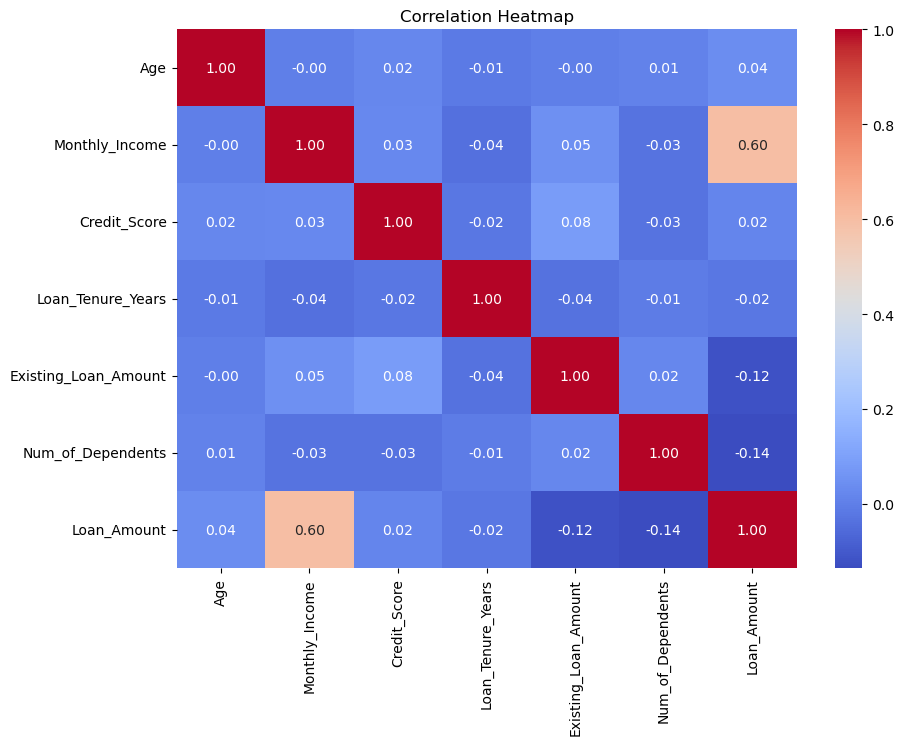

In [65]:

# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [67]:
# # Distribution plots
# feature_columns = ['Age', 'Monthly_Income', 'Credit_Score', 'Loan_Tenure_Years',
#                    'Existing_Loan_Amount', 'Num_of_Dependents', 'Loan_Amount']

# for col in feature_columns:
#     plt.figure()
#     sns.histplot(df[col], kde=True)
#     plt.title(f'Distribution of {col}')


# import os

# # Ensure the directory exists
# output_dir = 'loanpredictor/static/loanpredictor/images'
# os.makedirs(output_dir, exist_ok=True)

# # Save to static folder inside your app
# plt.savefig(os.path.join(output_dir, 'Age_distribution.png'))
# plt.show()
# plt.savefig(os.path.join(output_dir, 'Income_distribution.png'))
# plt.show()
# plt.savefig(os.path.join(output_dir, 'Credit_Score_distribution.png'))
# plt.show()
# plt.savefig(os.path.join(output_dir, 'Tenure_distribution.png'))
# plt.show()
# plt.savefig(os.path.join(output_dir, 'existingloan_distribution.png'))
# plt.show()
# plt.savefig(os.path.join(output_dir, 'dependents_distribution.png'))
# plt.show()
# plt.savefig(os.path.join(output_dir, 'loanamaount_distribution.png'))
# plt.show()

# plt.close()
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the directory exists
output_dir = 'loanpredictor/static/loanpredictor/images'
os.makedirs(output_dir, exist_ok=True)

# Feature columns to plot
feature_columns = ['Age', 'Monthly_Income', 'Credit_Score', 'Loan_Tenure_Years',
                   'Existing_Loan_Amount', 'Num_of_Dependents', 'Loan_Amount']

# Generate and save plots one by one
for col in feature_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    
    # Normalize column name to lowercase and replace spaces if needed
    file_name = f"{col}_distribution.png".replace(" ", "_")
    
    # Save each figure with a unique name
    plt.savefig(os.path.join(output_dir, file_name))
    plt.close()



<Figure size 640x480 with 0 Axes>

In [53]:
# ========== Train/Test Split ==========

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [35]:
# ========== Model Training ==========

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [36]:
# ========== Evaluation ==========

y_pred = model.predict(X_test)

print("\nModel Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")


Model Evaluation Metrics:
Mean Absolute Error (MAE): 13259.89
Mean Squared Error (MSE): 268044207.86
R2 Score: 0.30


In [37]:
# ========== Save Model and Scaler ==========

joblib.dump(model, 'loan_prediction_model.pkl')
joblib.dump(scaler, 'loan_scaler.pkl')

print("\nModel and scaler saved.")



Model and scaler saved.
